In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ─────────────────────────────────────────────────────────────
#  FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame()
    X["TI171"]   = df["TI171"]
    X["TI170"]   = df["TI170"]
    X["TI169"]   = df["TI169"]
    X["VI167X"]  = df["VI167X"]
    X["VI167Y"]  = df["VI167Y"]
    X["AZI165"]  = df["AZI165"]
    X["T_moy"]   = (df["TI171"] + df["TI170"] + df["TI169"]) / 3
    X["V_max"]   = df[["VI167X", "VI167Y"]].max(axis=1)
    X["AZI_abs"] = df["AZI165"].abs()
    X["DeltaT"]  = df["TI170"] - df["TI169"]
    return X

In [7]:
class SmartPredict:
 
    FEATURE_NAMES = ["TI171","TI170","TI169","VI167X","VI167Y","AZI165",
                     "T_moy","V_max","AZI_abs","DeltaT"]
    CLASS_NAMES   = ["FAIBLE", "MOYEN", "CRITIQUE"]
 
    def __init__(self, data_path="data/ocp_soufre_dataset.csv",
                 model_dir="models", random_state=42):
        self.data_path    = data_path
        self.model_dir    = model_dir
        self.random_state = random_state
        self.best_model   = None
        self.best_name    = None
        self.scaler       = StandardScaler()
        self.results      = {}
        os.makedirs(model_dir, exist_ok=True)
 
    # ── Chargement ────────────────────────────────────────────
    def load_data(self):
        df = pd.read_csv(self.data_path)
        X  = engineer_features(df)
        y  = df["etat_machine"].astype(int)
        print(f"📂 Données chargées : {len(df)} lignes, {X.shape[1]} features")
        print(f"   Distribution : {dict(y.value_counts().sort_index())}")
        return X.values, y.values
 
    # ── Définition des 3 modèles ──────────────────────────────
    def _build_models(self):
        return {
            "RandomForest": RandomForestClassifier(
                n_estimators=200, max_depth=12,
                min_samples_split=3, class_weight="balanced",
                random_state=self.random_state, n_jobs=-1
            ),
            "GradientBoosting": GradientBoostingClassifier(
                n_estimators=150, learning_rate=0.08,
                max_depth=5, subsample=0.85,
                random_state=self.random_state
            ),
            "SVM": Pipeline([
                ("scaler", StandardScaler()),
                ("svc",    SVC(kernel="rbf", C=10, gamma="scale",
                               probability=True, class_weight="balanced",
                               random_state=self.random_state))
            ])
        }
 
    # ── Matrice de confusion (plot + sauvegarde) ──────────────
    def _plot_confusion_matrix(self, y_test, y_pred, name, acc, f1):
        cm_array = confusion_matrix(y_test, y_pred)
 
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm_array,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=self.CLASS_NAMES,
            yticklabels=self.CLASS_NAMES,
            linewidths=0.5,
            linecolor="gray"
        )
        plt.title(
            f"Matrice de confusion — {name}\n"
            f"Accuracy : {acc*100:.1f}%  |  F1-Score : {f1*100:.1f}%",
            fontsize=12, fontweight="bold", pad=12
        )
        plt.xlabel("Classe prédite", fontsize=11)
        plt.ylabel("Classe réelle",  fontsize=11)
        plt.tight_layout()
 
        plot_path = os.path.join(self.model_dir, f"confusion_matrix_{name}.png")
        plt.savefig(plot_path, dpi=150)
        plt.show()
        print(f"     📊 Matrice sauvegardée → {plot_path}")
 
    # ── Entraînement + évaluation ─────────────────────────────
    def train(self):
        X, y = self.load_data()
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=self.random_state
        )
 
        models     = self._build_models()
        cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        all_scores = {}
 
        print("\n" + "═"*55)
        print("  COMPARAISON DES 3 MODÈLES")
        print("═"*55)
 
        for name, clf in models.items():
            clf.fit(X_train, y_train)
            y_pred  = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)
 
            acc     = accuracy_score(y_test, y_pred)
            f1      = f1_score(y_test, y_pred, average="weighted")
            auc     = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
            cv_mean = cross_val_score(clf, X, y, cv=cv, scoring="f1_weighted").mean()
            cm      = confusion_matrix(y_test, y_pred).tolist()
            report  = classification_report(y_test, y_pred,
                                            target_names=self.CLASS_NAMES, output_dict=True)
 
            self.results[name] = {
                "accuracy": round(acc, 4),
                "f1_weighted": round(f1, 4),
                "auc_roc": round(auc, 4),
                "cv_f1": round(cv_mean, 4),
                "confusion_matrix": cm,
                "classification_report": report,
                "model": clf
            }
            all_scores[name] = f1
 
            print(f"\n  🔷 {name}")
            print(f"     Accuracy  : {acc*100:.1f}%")
            print(f"     F1-Score  : {f1*100:.1f}%")
            print(f"     AUC-ROC   : {auc*100:.1f}%")
            print(f"     CV F1     : {cv_mean*100:.1f}%")
 
            # ── Affichage matrice de confusion ─────────────────
            self._plot_confusion_matrix(y_test, y_pred, name, acc, f1)
 
        # ── Sélection du meilleur ──────────────────────────────
        self.best_name  = max(all_scores, key=all_scores.get)
        self.best_model = self.results[self.best_name]["model"]
        print(f"\n  ✅ Meilleur modèle : {self.best_name} "
              f"(F1={all_scores[self.best_name]*100:.1f}%)")
        print("═"*55)
 
        self._save(X_train, y_train)
        return self.results
 
    # ── Feature importance ────────────────────────────────────
    def _feature_importance(self):
        model = self.best_model
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
        elif hasattr(model, "named_steps"):
            imp = np.ones(len(self.FEATURE_NAMES)) / len(self.FEATURE_NAMES)
        else:
            imp = np.ones(len(self.FEATURE_NAMES)) / len(self.FEATURE_NAMES)
        return dict(zip(self.FEATURE_NAMES, [round(float(v), 4) for v in imp]))
 
    # ── Sauvegarde ────────────────────────────────────────────
    def _save(self, X_train, y_train):
        with open(f"{self.model_dir}/smartpredict_model.pkl", "wb") as f:
            pickle.dump(self.best_model, f)
 
        voting_components = {k: v["model"] for k, v in self.results.items()}
        with open(f"{self.model_dir}/voting_components.pkl", "wb") as f:
            pickle.dump(voting_components, f)
 
        metrics_out = {}
        for name, res in self.results.items():
            metrics_out[name] = {k: v for k, v in res.items() if k != "model"}
        metrics_out["best_model"] = self.best_name
        with open(f"{self.model_dir}/metrics.json", "w", encoding="utf-8") as f:
            json.dump(metrics_out, f, indent=2, ensure_ascii=False)
 
        fi = self._feature_importance()
        fi_df = pd.DataFrame(list(fi.items()), columns=["feature", "importance"])
        fi_df.sort_values("importance", ascending=False, inplace=True)
        fi_df.to_csv(f"{self.model_dir}/feature_importance.csv", index=False)
 
        print(f"\n💾 Modèle sauvegardé  → {self.model_dir}/smartpredict_model.pkl")
        print(f"💾 Métriques          → {self.model_dir}/metrics.json")
        print(f"💾 Feature importance → {self.model_dir}/feature_importance.csv")
 
    # ── Prédiction unitaire ───────────────────────────────────
    def predict_one(self, sensor_dict: dict):
        row = pd.DataFrame([sensor_dict])
        X   = engineer_features(row).values
        proba  = self.best_model.predict_proba(X)[0].tolist()
        label  = int(np.argmax(proba))
        return label, proba, self.CLASS_NAMES[label]
 
 



🚀 Lancement de l'entraînement...
📂 Données chargées : 2319 lignes, 10 features
   Distribution : {0: np.int64(1873), 1: np.int64(297), 2: np.int64(149)}

═══════════════════════════════════════════════════════
  COMPARAISON DES 3 MODÈLES
═══════════════════════════════════════════════════════

  🔷 RandomForest
     Accuracy  : 99.1%
     F1-Score  : 99.1%
     AUC-ROC   : 99.7%
     CV F1     : 99.8%


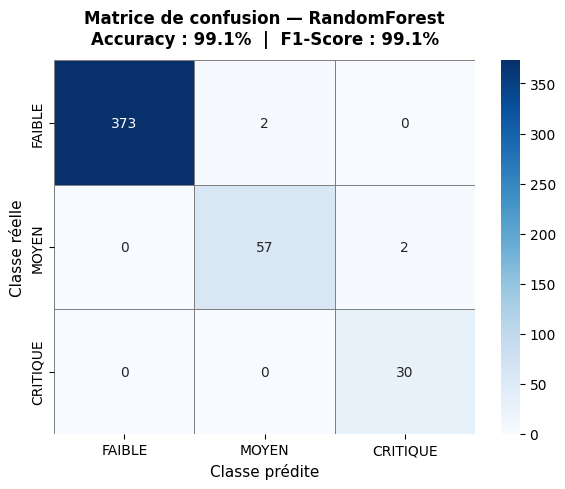

     📊 Matrice sauvegardée → models\confusion_matrix_RandomForest.png

  🔷 GradientBoosting
     Accuracy  : 99.1%
     F1-Score  : 99.1%
     AUC-ROC   : 100.0%
     CV F1     : 99.9%


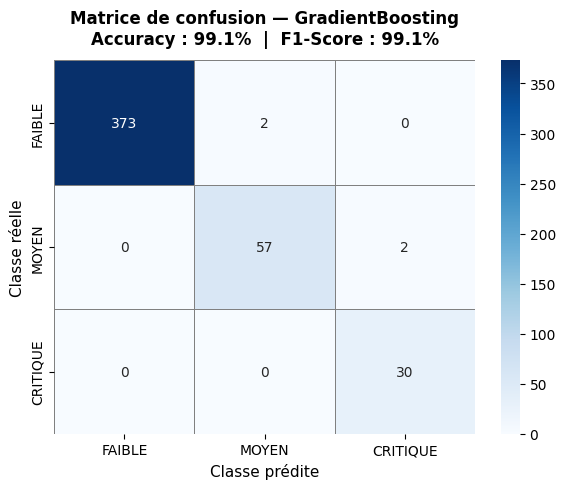

     📊 Matrice sauvegardée → models\confusion_matrix_GradientBoosting.png

  🔷 SVM
     Accuracy  : 99.1%
     F1-Score  : 99.1%
     AUC-ROC   : 100.0%
     CV F1     : 99.5%


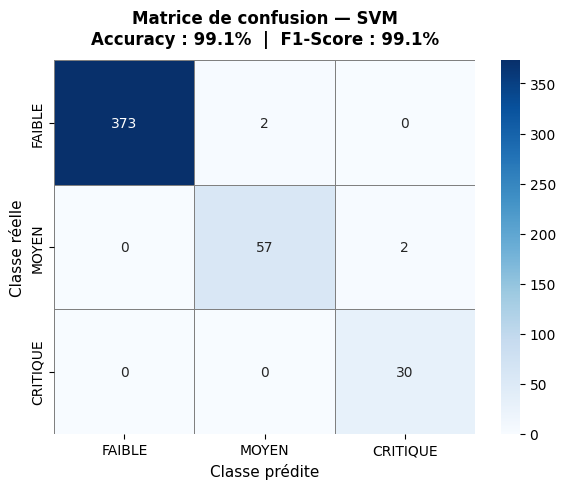

     📊 Matrice sauvegardée → models\confusion_matrix_SVM.png

  ✅ Meilleur modèle : RandomForest (F1=99.1%)
═══════════════════════════════════════════════════════

💾 Modèle sauvegardé  → models/smartpredict_model.pkl
💾 Métriques          → models/metrics.json
💾 Feature importance → models/feature_importance.csv

✅ Entraînement terminé.


In [8]:
# ─────────────────────────────────────────────────────────────
#  POINT D'ENTRÉE
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("\n🚀 Lancement de l'entraînement...")
    sp = SmartPredict()
    sp.train()
    print("\n✅ Entraînement terminé.")